# CTR Prediction and Probability Calibration for Advertising Auction"

## Project Context

Company **Advandex** — AdTech platform conducting Real-Time Bidding (RTB) auctions. The auction winner is determined by the formula: `Bid × Predicted CTR`. Task: Build a binary classification model, predicting the probability of clicking on an advertisement banner, and **calibrate** it so that predicted probabilities correspond to real click frequencies.


## Data

- **Source:** ad_click_dataset — analytical showcase of advertisement banner impressions
- **Target Variable:** `click` (1 — click, 0 — no)
- **Class Imbalance:** present
- **Feature:** data is anonymized (categories like `f028772b`)

## Evaluation Metrics


- PR-AUC: Primary. Accounts for class imbalance, focuses on clicks
- Log Loss: Probability quality for bidding calculation
- Brier Score: Accuracy + calibration, direct financial value

# Project Structure

## 1. Environment Setup and Data Loading

**LIBRARY IMPORTS**

In [1]:
!pip install phik -q

In [ ]:
# Standard Libraries
# Data Processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
!pip install category-encoders
from category_encoders import TargetEncoder

# Feature Selection
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif, f_classif, SequentialFeatureSelector
from sklearn.feature_selection import RFE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Calibration
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
from scipy.special import expit

# Evaluation and Hyperparameter Tuning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import (
    average_precision_score,
    log_loss,
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score,
)

# Correlation Analysis
import phik

# Model Saving
import joblib

**DISPLAY SETTINGS**

In [3]:
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='whitegrid', palette='muted')

**REQUIREMENTS FILE**

pandas==2.2.2
numpy==1.26.4
scikit-learn==1.5.1
matplotlib==3.9.1
seaborn==0.13.2

**REPRODUCIBILITY CONSTANT**

In [ ]:
RANDOM_SEED = 42
print(f'RANDOM_SEED = {RANDOM_SEED}')

**DATA LOADING**

In [5]:
DATA_PATH = '/datasets/ds_s16_ad_click_dataset.csv'

df = pd.read_csv(DATA_PATH)

print(f'Dataset size: {df.shape[0]:,} rows, {df.shape[1]} columns')
df.head()

Dataset size: 50,000 rows, 34 columns


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,10052627552648869888.0000,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,488a9a3e,31025cda,1,0,17614,320,50,1993,2,1063,-1,33,-0.9968,A,0.6666,0,0.8173,0.9933,Z,-0.6200,0.4337,0.2740
1,10105971003478261760.0000,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,75bb1b58,2ee63ff8,1,0,15701,320,50,1722,0,35,-1,79,-0.3913,C,5.1468,1,-0.8839,-0.8257,X,0.5765,-0.3186,-0.1329
2,10120475683957065728.0000,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,285263b0,d780319b,1,0,17914,320,50,2043,2,39,100084,32,-2.1127,D,7.1693,0,-0.8594,-0.3384,Y,-0.4400,-0.3454,0.3405
3,1021995395003627776.0000,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,a99f214a,18190986,f4fffcd0,1,0,21611,320,50,2480,3,297,100111,61,0.3327,A,-0.2907,1,0.0628,0.0629,Y,0.5520,0.7334,-0.1985
4,10234552355176744960.0000,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b66e5482,a0f5f879,1,0,15702,320,50,1722,0,35,100084,79,1.1666,A,6.3191,1,-0.6753,0.7971,X,0.6408,0.2980,-0.1369


In [ ]:
# Verify successful loading
assert df.shape == (50000, 34), 'Dataset size does not match expected'
assert 'click' in df.columns, 'Target variable is missing'

## 2. Exploratory Data Analysis (EDA)

#### 2.1 Describe basic dataset information
- Determine the number of objects and features in the data.
- Find out what data types are represented (numerical, categorical).
- Give a general description: indicate what is known about users and advertising.

#### 2.2 Target Variable Analysis
- Analyze how the target variable is distributed.
- Determine if there is class imbalance. This is important for metric selection.
- Calculate the proportion of ads that were clicked and the proportion that were not.

#### 2.3 Feature Analysis
- Determine if all features are needed for model training. Are there any obviously useless ones?
- Describe which features are categorical and which are numerical.
- Conduct primary selection: remove unnecessary features.

#### 2.4 Missing Values Analysis
- Check the proportion of missing values in each feature.
- Choose the correct strategy for filling missing values — removal, mean, median, mode. Justify the choice.

#### 2.5 Categorical Features Analysis
- Determine how many unique values are in each categorical feature.
- Indicate which features can be One-Hot encoded and which require special methods due to high cardinality.

#### 2.6 Outliers and Distributions Analysis
- Check if there are obvious outliers in numerical features.
- Describe how outliers are distributed — normally, asymmetrically, or otherwise.

#### 2.7 Correlations
- Determine which features correlate with the target variable.
- Identify highly correlated features that can be removed, if any.

#### 2.8 EDA Conclusions
- Briefly describe key findings.
- Choose features that look most promising for the model. Justify the choice.
- Determine data preprocessing actions that need to be performed.

**BASIC DATASET INFORMATION**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  object 
 6   site_domain       50000 non-null  object 
 7   site_category     50000 non-null  object 
 8   app_id            50000 non-null  object 
 9   app_domain        50000 non-null  object 
 10  app_category      50000 non-null  object 
 11  device_id         50000 non-null  object 
 12  device_ip         50000 non-null  object 
 13  device_model      50000 non-null  object 
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64 

The dataset contains 50,000 records of advertising banner impressions and 34 features. Features describe: the site, the application (app), the user's device, banner and auction parameters (C1, C14–C21), and machine-generated features. Data is anonymized — categorical values are represented as hashes of the form `f028772b`.

**TARGET VARIABLE ANALYSIS**

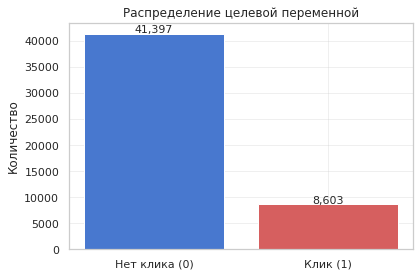

No click (0): 41,397 (82.8%)
Click (1): 8,603 (17.2%)
Class ratio: 1 to 4.8


In [8]:
click_counts = df['click'].value_counts()
click_pct = df['click'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
plt.bar(['No click (0)', 'Click (1)'], click_counts.values, color=['# 4878CF', '#D65F5F'])
plt.title('Target Variable Distribution')
plt.ylabel('Count')
for i, v in enumerate(click_counts.values):
    plt.text(i, v + 200, f'{v:,}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

print(f'No click (0): {click_counts[0]:,} ({click_pct[0]:.1f}%)')
print(f'Click (1): {click_counts[1]:,} ({click_pct[1]:.1f}%)')
print(f'Class ratio: 1 to {click_counts[0]/click_counts[1]:.1f}')

There is a pronounced class imbalance: 82.8% of impressions without a click vs 17.2% with a click (ratio ~1:5). This confirms our decision to use PR-AUC as the primary metric.

**FEATURE ANALISYS**

In [9]:
# preliminary analysis of numerical variables
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,50000.0000,NaN,NaN,NaN,9215402302107276288.0000,5328516395922776064.0000,31910769195310.0000,4580648973216844800.0000,9243014535888650240.0000,13809198391134916608.0000,18446516750890600448.0000
click,50000.0000,NaN,NaN,NaN,0.1721,0.3774,0.0000,0.0000,0.0000,0.0000,1.0000
hour,50000.0000,NaN,NaN,NaN,14102559.0435,296.7892,14102100.0000,14102304.0000,14102602.0000,14102814.0000,14103023.0000
C1,50000.0000,NaN,NaN,NaN,1004.9701,1.1102,1001.0000,1005.0000,1005.0000,1005.0000,1012.0000
banner_pos,50000.0000,NaN,NaN,NaN,0.2914,0.5142,0.0000,0.0000,0.0000,1.0000,7.0000
site_id,50000,1160,85f751fd,18011,NaN,NaN,NaN,NaN,NaN,NaN,NaN
site_domain,50000,1013,c4e18dd6,18645,NaN,NaN,NaN,NaN,NaN,NaN,NaN
site_category,50000,18,50e219e0,20457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
app_id,50000,976,ecad2386,31989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
app_domain,50000,67,7801e8d9,33763,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Target Variable
TARGET = 'click'

# Categorical features
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Numerical features (excluding target)
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [col for col in num_cols if col != TARGET]

print(f'Categorical ({len(cat_cols)}): {cat_cols}')
print(f'Numerical ({len(num_cols)}): {num_cols}')

Categorical (11): ['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'ml_feature_2', 'ml_feature_7']
Numerical (22): ['id', 'hour', 'C1', 'banner_pos', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']


**CATEGORICAL FEATURES**

In [11]:
for col in cat_cols:
    unique_vals = df[col].unique()
    print(f'{col} ({len(unique_vals)} unique):')
    print(unique_vals[:10], '...' if len(unique_vals) > 10 else '')

site_id (1160 unique):
['d9750ee7' '1fbe01fe' '85f751fd' '543a539e' 'e59ef3fc' 'e151e245'
 '5114c672' '0eb72673' 'c63170c5' '518d6168'] ...
site_domain (1013 unique):
['98572c79' 'f3845767' 'c4e18dd6' 'c7ca3108' '0a4015b2' '7e091613'
 '3f2f3819' 'd2f72222' 'a9bba545' '92c9e92d'] ...
site_category (18 unique):
['f028772b' '28905ebd' '50e219e0' '3e814130' '335d28a8' '0569f928'
 '76b2941d' 'a818d37a' '75fa27f6' 'f66779e6'] ...
app_id (976 unique):
['ecad2386' '39cfef32' 'fbbccc58' '5e3f096f' 'cf0327f9' '95b5e741'
 'a0fc55e5' 'd1763ed2' 'bbcfa7a2' '1779deee'] ...
app_domain (67 unique):
['7801e8d9' 'd9b5648e' '2347f47a' 'c6824def' 'b9528b13' '45a51db4'
 'aefc06bd' '5c5a694b' 'ae637522' '82e27996'] ...
app_category (22 unique):
['07d7df22' '0f2161f8' 'cef3e649' 'f95efa07' '8ded1f7a' '75d80bbe'
 'd1327cf5' 'dc97ec06' '09481d60' '879c24eb'] ...
device_id (8580 unique):
['a99f214a' '64c873f6' 'efd5dc79' 'd533161f' 'fb119767' '58d0a134'
 '18feb402' '50c4ddcc' 'c9ce98f9' 'e6e00475'] ...
device_i

Features for preliminary removal:

**`hour`** — timestamp. From the table: min=14102100, max=14103023 — this appears to be data from a single time period. Variance is minimal, no predictive power. Can be removed.

**`device_ip`** — 41,455 unique values out of 50,000 rows. This is nearly unique per record and cannot be encoded without overfitting. Should be removed.

**`device_id`** — 8,580 unique values. Same situation. Removing.

**`id`** — unique impression identifier, simply a sequential number. No relationship with click by definition. Should be removed.

In [12]:
drop_cols = ['id', 'hour', 'device_ip', 'device_id']
df = df.drop(columns=drop_cols)

In [13]:
# Update column lists after removal
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = [col for col in df.select_dtypes(include='number').columns if col != TARGET]

cardinality = pd.DataFrame({
    'feature': cat_cols,
    'unique_count': [df[col].nunique() for col in cat_cols]
}).sort_values('unique_count')

# Threshold for OHE vs Target Encoding (set to 10)
threshold = 10
cardinality['method'] = cardinality['unique_count'].apply(
    lambda x: 'One-Hot Encoding' if x <= threshold else 'Target Encoding'
)

print(cardinality.to_string(index=False))

ohe_cols = cardinality[cardinality['method'] == 'One-Hot Encoding']['feature'].tolist()
te_cols  = cardinality[cardinality['method'] == 'Target Encoding']['feature'].tolist()

      feature  unique_count          method
 ml_feature_7           3 One-Hot Encoding
 ml_feature_2           5 One-Hot Encoding
site_category          18  Target Encoding
 app_category          22  Target Encoding
   app_domain          67  Target Encoding
       app_id         976  Target Encoding
  site_domain        1013  Target Encoding
      site_id        1160  Target Encoding
 device_model        2521  Target Encoding


For two features with low cardinality (≤10 unique values) we will use One-Hot Encoding:
`ml_feature_2` (5), `ml_feature_7` (3).

For all remaining high-cardinality features, Target Encoding is appropriate.

**MISSING VALUES ANALYSIS**

In [14]:
missing = df.isnull().sum()
print(f'Total missing values: {missing.sum()}')

Total missing values: 0


The table already showed no missing values. The imputation step in the pipeline could be skipped, however `SimpleImputer` is still included in the Pipeline as a safeguard in case missing values appear in new data.

**OUTLIER AND DISTRIBUTION ANALYSIS**

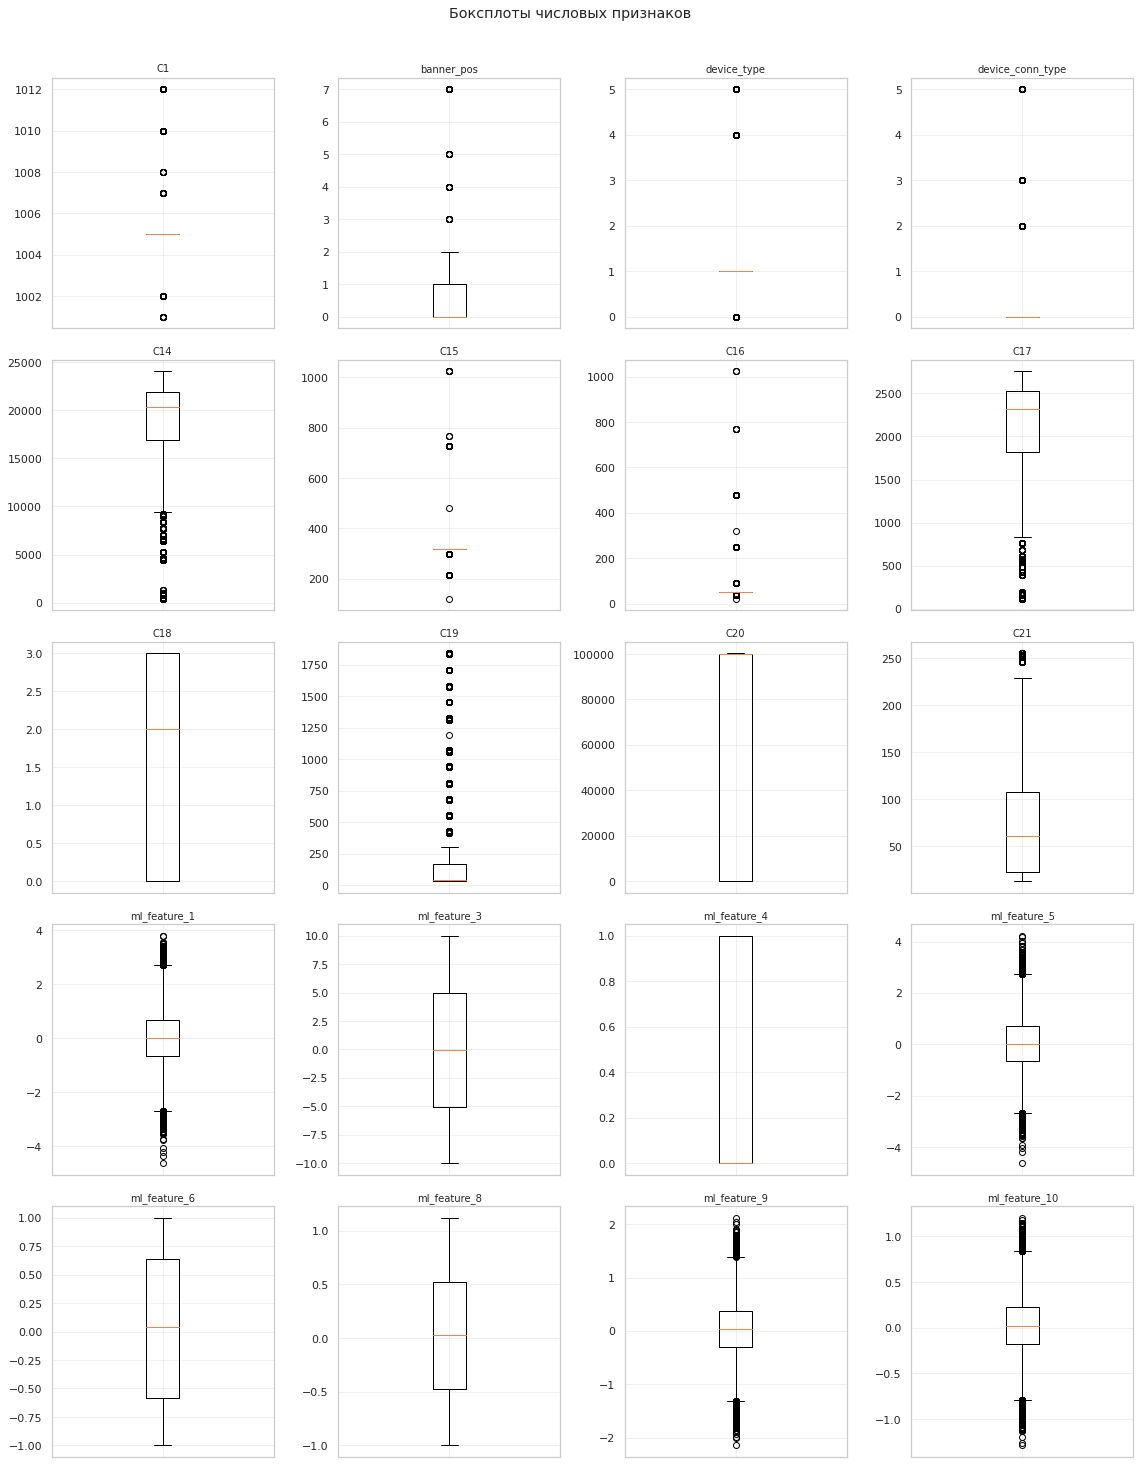

In [15]:
fig, axes = plt.subplots(len(num_cols) // 4 + 1, 4,
                         figsize=(16, 4 * (len(num_cols) // 4 + 1)))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticklabels([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots of Numerical Features', y=1.01)
plt.tight_layout()
plt.show()

In [16]:
# Outlier proportion by IQR
def outlier_rate(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    mask = (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)
    return mask.mean() * 100

outliers = pd.Series(
    {col: outlier_rate(df[col]) for col in num_cols}
).sort_values(ascending=False).round(2)

print('Outlier proportion by IQR (%):')
outliers

Outlier proportion by IQR (%):


C19                18.0300
device_conn_type   13.9600
C17                 8.4500
C14                 8.3400
C1                  8.3300
device_type         7.9400
C15                 6.4300
C16                 5.4300
ml_feature_9        0.7700
C21                 0.7600
ml_feature_5        0.7200
ml_feature_10       0.7000
ml_feature_1        0.6900
banner_pos          0.1700
ml_feature_3        0.0000
ml_feature_4        0.0000
ml_feature_6        0.0000
ml_feature_8        0.0000
C18                 0.0000
C20                 0.0000
dtype: float64

Based on the data description, features `C1, C14–C21` are discrete auction codes, so their 'outliers' are valid
rare categories that should not be removed. All `ml_feature` columns follow a near-normal distribution with mean ~0; some (like `C20`) contain negative values, which likely indicate the absence of certain data rather than a mathematical outlier. We will not remove them — they most likely carry meaningful signal in advertising data. The remaining features (`banner_pos`, `device_conn_type`, `device_type`) also contain outliers that can be treated as rare but valid values.

Since all features have different scales, we will apply `StandardScaler`.

**CORRELATION ANALYSIS**

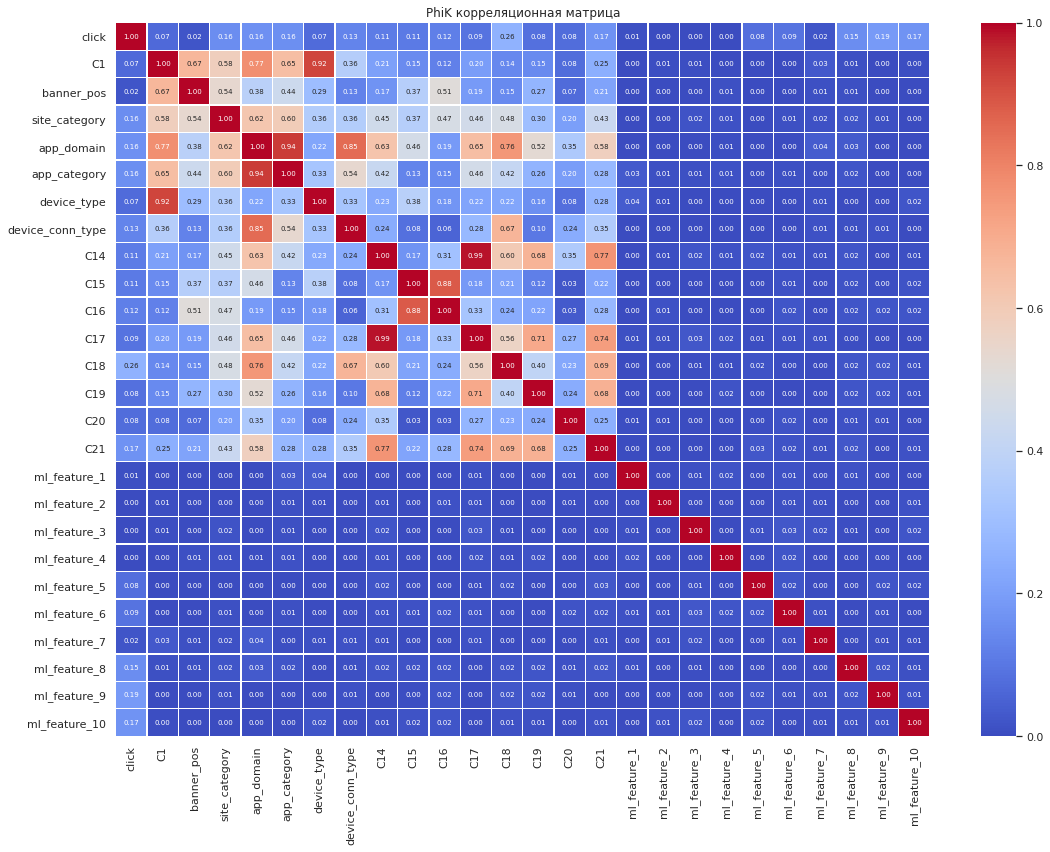

In [17]:
# Exclude high-cardinality categorical features for correlation analysis
high_cardinality = ['site_id', 'site_domain', 'app_id', 'device_model']
cols_for_phik = [col for col in df.columns if col not in high_cardinality]

phik_matrix = df[cols_for_phik].phik_matrix(interval_cols=num_cols)

plt.figure(figsize=(16, 12))
sns.heatmap(
    phik_matrix,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='coolwarm',
    vmin=0, vmax=1,
    linewidths=0.3
)
plt.title('PhiK Correlation Matrix')
plt.tight_layout()
plt.show()

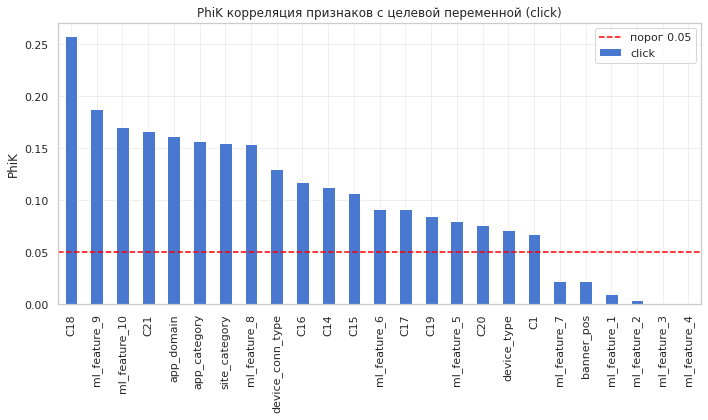

In [18]:
# display correlation with target variable separately for clarity
phik_with_target = phik_matrix['click'].drop('click').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
phik_with_target.plot(kind='bar', color='# 4878CF')
plt.title('PhiK Correlation of Features with Target Variable (click)')
plt.ylabel('PhiK')
plt.axhline(0.05, color='red', linestyle='--', label='threshold 0.05')
plt.legend()
plt.tight_layout()
plt.show()

Feature correlations with the target variable are generally low — this is typical for CTR tasks where the signal is weak and distributed across many features, especially since several high-cardinality features had to be excluded from the analysis. No strongly inter-correlated numerical features were found. The most informative features by correlation with `click` appear to be `C18, ml_feature_9, ml_feature_10, and C21`.

**EDA CONCLUSIONS**

The dataset is well-prepared: no missing values, outliers in numerical features are not critical and carry meaningful signal — we will not remove them. The main characteristic of the data is class imbalance (17.2% clicks), which directly determines our choice of metrics (PR-AUC).

PhiK analysis showed that auction parameters C18, C21 and selected ml_feature characteristics have the highest (though not high, ~0.20) association with the target variable. Features with very weak correlation will be selected or filtered out at the next stage.

It is worth noting the C-features: despite being numerical in type, their values are codes. They resemble categorical rather than numerical features. However, to avoid further complications (these codes are anonymized and we do not know their nature precisely; arithmetic operations on them are meaningless in principle), we will keep them as-is and apply StandardScaler for normalization. High-cardinality features (site_id, site_domain, app_id, device_model) were excluded from PhiK due to computational constraints, but remain in the model — they will be processed via Target Encoding.

Features id, hour, device_ip, device_id were removed: they are either technical identifiers or so unique that they would only cause overfitting.

## 3. Train/Test Split

#### 3.1 Split the data
- First, separate the test set — it should contain 20% of the data.
- Use the remaining 80% for training.
- Use stratified splitting to preserve class balance.
- **Do not use the test set until final evaluation!**

#### 3.2 Verify the split
- Verify that the target variable distribution is preserved in each split.
- Print the sizes of each split.

In [19]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_SEED
)

print(f'Train: {X_train.shape[0]:,} rows ({X_train.shape[0]/len(df)*100:.0f}%)')
print(f'Test: {X_test.shape[0]:,} rows ({X_test.shape[0]/len(df)*100:.0f}%)')

Train: 40,000 rows (80%)
Test: 10,000 rows (20%)


In [20]:
# Check class balance
for name, y_part in [('Full dataset', y), ('Train', y_train), ('Test', y_test)]:
    pct = y_part.mean() * 100
    print(f'{name}: {pct:.1f}% clicks')

Full dataset: 17.2% clicks
Train: 17.2% clicks
Test: 17.2% clicks


## 4. Data Preprocessing — Building Pipelines

#### 4.1 Create a preprocessing pipeline

**For numerical features:**
- Fill missing values correctly — with mean, median, or another method.
- Scale data using `StandardScaler`.
- Handle outliers if necessary.

**For categorical features:**
- Fill missing values correctly — with a default value or mode.
- Apply encoding:
  - One-Hot Encoding for low-cardinality features.
  - Target Encoding for high-cardinality features.

#### 4.2 Combine pipelines
- Use `sklearn.pipeline.Pipeline` and `ColumnTransformer`.
- **Important:** use information about missing values and categories only from the training set!

In [21]:
# Cardinality threshold for encoding method selection
OHE_THRESHOLD = 10

ohe_cols = [col for col in cat_cols if X_train[col].nunique() <= OHE_THRESHOLD]
te_cols  = [col for col in cat_cols if X_train[col].nunique() >  OHE_THRESHOLD]

print(f'OHE ({len(ohe_cols)}): {ohe_cols}')
print(f'Target Encoding ({len(te_cols)}): {te_cols}')
print(f'Numerical ({len(num_cols)}): {num_cols}')

OHE (2): ['ml_feature_2', 'ml_feature_7']
Target Encoding (7): ['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_model']
Numerical (20): ['C1', 'banner_pos', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']


In [22]:
# Pipeline for numerical features
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline for OHE features
ohe_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse=False))
])

# Pipeline for Target Encoding
te_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', TargetEncoder(smoothing=10))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('ohe', ohe_pipeline, ohe_cols),
        ('te',  te_pipeline,  te_cols),
    ],
    remainder='drop'
)

At the preprocessing stage, several methods were applied for:

- **Numerical Variables:** median imputation was used (as it is robust to outliers) and StandardScaler for normalization.
- **Categorical Features:** OHE was applied to `ml_feature_2` and `ml_feature_7` as they have low cardinality and will not cause dimensionality explosion. For all other high-cardinality categorical features, **Target Encoding** was used. `smoothing=10` was applied to smooth estimates for rare categories and reduce potential overfitting.

`ColumnTransformer` is fitted only on `X_train` to prevent data leakage.

## 5. Feature Selection

#### 5.1 Apply filter methods
- Compute the correlation of each feature with the target variable.
- Select the top features. Explain why you stopped at that number.
- Remove features with very low variance using `VarianceThreshold`.

#### 5.2 Apply wrapper methods
- Use wrapper methods to find the optimal feature set.

#### 5.3 Select the final feature set
- Combine the results of the methods.
- Select the features that passed filtering.

In [23]:
# VarianceThreshold — applied before scaling on raw numerical data

var_selector = VarianceThreshold(threshold=0.0)
var_selector.fit(X_train[num_cols])
removed = [col for col, support in zip(num_cols, var_selector.get_support()) if not support]
print(f'Features with zero variance: {len(removed)}')

Features with zero variance: 0


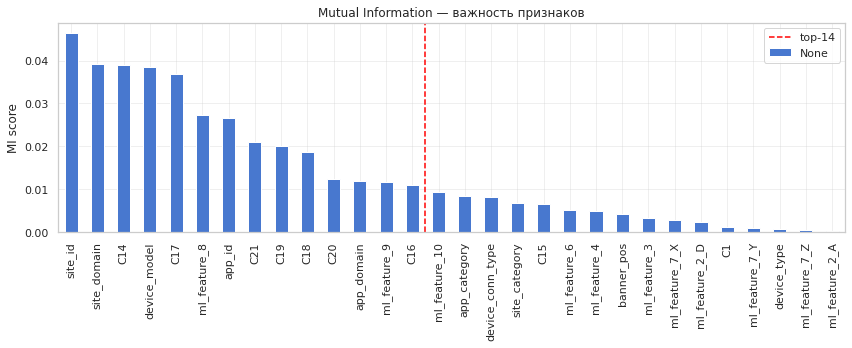

Top-14 features:
['site_id', 'site_domain', 'C14', 'device_model', 'C17', 'ml_feature_8', 'app_id', 'C21', 'C19', 'C18', 'C20', 'app_domain', 'ml_feature_9', 'C16']


In [24]:
# SelectKBest via pipeline — without prior fit_transform
k = 14
pipe_for_selection = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(mutual_info_classif, k=k))
])

pipe_for_selection.fit(X_train, y_train)

# Get feature names
ohe_feature_names = pipe_for_selection.named_steps['preprocessor']\
    .named_transformers_['ohe']['encoder'].get_feature_names(ohe_cols).tolist()
feature_names = num_cols + ohe_feature_names + te_cols

scores = pd.Series(
    pipe_for_selection.named_steps['selector'].scores_,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
scores.head(30).plot(kind='bar', color='# 4878CF')
plt.title('Mutual Information — Feature Importance')
plt.ylabel('MI score')
plt.axvline(k - 0.5, color='red', linestyle='--', label=f'top-{k}')
plt.legend()
plt.tight_layout()
plt.show()

selected_kbest = scores.head(k).index.tolist()
print(f'Top-{k} features:\n{selected_kbest}')

In [25]:
# create RFE inside the pipeline
rfe_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('rfe', RFE(
        estimator=LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_SEED),
        n_features_to_select=14
    ))
])
rfe_pipeline.fit(X_train, y_train)

selected_rfe = [feature_names[i] for i, v in enumerate(rfe_pipeline.named_steps['rfe'].get_support()) if v]
print(f'RFE selected {len(selected_rfe)} features:')
selected_rfe

RFE selected 14 features:


['ml_feature_2_A',
 'ml_feature_2_C',
 'ml_feature_2_D',
 'ml_feature_2_E',
 'ml_feature_7_X',
 'ml_feature_7_Y',
 'ml_feature_7_Z',
 'site_id',
 'site_domain',
 'site_category',
 'app_id',
 'app_domain',
 'app_category',
 'device_model']

In [26]:
# Final feature set
rfe_original = set()
for f in selected_rfe:
    # OHE features like ml_feature_2_A → original ml_feature_2
    matched = [col for col in ohe_cols if f.startswith(col)]
    if matched:
        rfe_original.add(matched[0])
    else:
        rfe_original.add(f)

print(f'RFE (original features): {rfe_original}')

# Final feature set
final_features = list(set(selected_kbest) | rfe_original)
print(f'Final feature set: {len(final_features)} features')
print(final_features)

# Distribute by type
num_final = [f for f in final_features if f in num_cols]
ohe_final = [f for f in final_features if f in ohe_cols]
te_final  = [f for f in final_features if f in te_cols]

print(f'\nNumerical: {num_final}')
print(f'OHE:      {ohe_final}')
print(f'TE:       {te_final}')

preprocessor_final = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_final),
        ('ohe', ohe_pipeline, ohe_final),
        ('te',  te_pipeline,  te_final),
    ],
    remainder='drop'
)

RFE (original features): {'device_model', 'app_id', 'ml_feature_7', 'app_category', 'site_id', 'app_domain', 'site_category', 'site_domain', 'ml_feature_2'}
Final feature set: 18 features
['C19', 'device_model', 'app_id', 'C16', 'site_id', 'app_domain', 'site_category', 'C14', 'ml_feature_9', 'site_domain', 'ml_feature_2', 'C17', 'ml_feature_8', 'C21', 'ml_feature_7', 'app_category', 'C20', 'C18']

Numerical: ['C19', 'C16', 'C14', 'ml_feature_9', 'C17', 'ml_feature_8', 'C21', 'C20', 'C18']
OHE:      ['ml_feature_2', 'ml_feature_7']
TE:       ['device_model', 'app_id', 'site_id', 'app_domain', 'site_category', 'site_domain', 'app_category']


SelectKBest selected the top-14 features by Mutual Information: these are auction parameters (C14, C17, C18, C19, C20, C21) and categorical site and app characteristics. RFE confirmed the importance of categorical features (site_id, site_domain, app_id, etc.) and additionally highlighted ml_feature_2 and ml_feature_7.

Since the methods operate in different feature spaces, their direct intersection is not possible; therefore the final feature set was formed as the union of both methods' results: 18 features in total.

## 6. Baseline Model Training

### 6.1 Train `DummyClassifier`
- This establishes the simplest possible baseline performance level.

### 6.2 Train `LogisticRegression`
- Use the selected features for training.
- Apply 5-fold cross-validation.
- Calculate PR-AUC. If needed, additionally compute Precision, Recall, and F1-score.
- Note: for correct cross-validation, preprocessing must be combined with the classifier in a Pipeline.

### 6.3 Train `SVC`

- Train SVC with a linear kernel.
- Apply 5-fold cross-validation and compute the same PR-AUC metric. If needed, additionally compute Precision, Recall, and F1-score.
- Model calibration will be performed later, so use `probability=False` here.

### 6.4 Compare Models
- Verify that `LogisticRegression` outperforms `DummyClassifier`.
- Compare the performance of `LogisticRegression` with `SVC`.

In [27]:
full_pipeline_logreg = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(mutual_info_classif, k=14)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))
])

full_pipeline_svc = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(mutual_info_classif, k=14)),
    ('classifier', LinearSVC(max_iter=2000, random_state=RANDOM_SEED))
])

In [28]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

scoring = {
    'PR-AUC': 'average_precision',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

def print_cv_results(name, cv_results):
    print(f'=== {name} ===')
    for metric in ['PR-AUC', 'precision', 'recall', 'f1']:
        mean = cv_results[f'test_{metric}'].mean()
        std  = cv_results[f'test_{metric}'].std()
        print(f'  {metric}: {mean:.4f} ± {std:.4f}')
    print()

**DummyClassifier**

In [29]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
cv_dummy = cross_validate(dummy, X_train, y_train, cv=cv, scoring=scoring)
print_cv_results('DummyClassifier', cv_dummy)

=== DummyClassifier ===
  PR-AUC: 0.1720 ± 0.0001
  precision: 0.0000 ± 0.0000
  recall: 0.0000 ± 0.0000
  f1: 0.0000 ± 0.0000



/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined a

**LogisticRegression**

In [30]:
cv_logreg = cross_validate(full_pipeline_logreg, X_train, y_train, cv=cv, scoring=scoring)
print_cv_results('LogisticRegression', cv_logreg)

=== LogisticRegression ===
  PR-AUC: 0.3737 ± 0.0277
  precision: 0.5318 ± 0.0464
  recall: 0.1184 ± 0.0296
  f1: 0.1928 ± 0.0426



**LinearSVC**

In [31]:
cv_svc = cross_validate(full_pipeline_svc, X_train, y_train, cv=cv, scoring=scoring)
print_cv_results('LinearSVC', cv_svc)

/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:985: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "


=== LinearSVC ===
  PR-AUC: 0.3807 ± 0.0063
  precision: 0.5660 ± 0.0183
  recall: 0.0942 ± 0.0134
  f1: 0.1611 ± 0.0204



**MODEL COMPARISON**

In [32]:
results = pd.DataFrame({
    'DummyClassifier':   {m: cv_dummy[f'test_{m}'].mean() for m in scoring},
    'LogisticRegression': {m: cv_logreg[f'test_{m}'].mean() for m in scoring},
    'LinearSVC':         {m: cv_svc[f'test_{m}'].mean() for m in scoring},
}).T.round(4)
display(results)

,PR-AUC,precision,recall,f1
DummyClassifier,0.1720,0.0000,0.0000,0.0000
LogisticRegression,0.3737,0.5318,0.1184,0.1928
LinearSVC,0.3807,0.5660,0.0942,0.1611


**DummyClassifier** predicts only the majority class (0), so Precision, Recall, and F1 are zero, and PR-AUC = 0.172.

**LogisticRegression** achieves PR-AUC = 0.374 — nearly 2× better than Dummy. High Precision (0.532) with low Recall (0.118) indicates that the model is conservative: when it predicts a click it is usually correct, but it misses most actual clicks.

**LinearSVC** shows a nearly identical result: PR-AUC = 0.381. Slightly higher Precision (0.566) but even lower Recall (0.094). The model is even more conservative in predicting clicks.

Both models significantly outperform the baseline and are comparable to each other. LogisticRegression is marginally lower on PR-AUC but has the advantage of directly outputting calibrated probabilities, whereas LinearSVC will require additional calibration.

## 7. Hyperparameter Tuning: Grid Search with Cross-Validation

#### 7.1 Define the hyperparameter grid
Define the key parameters that affect the performance of `LogisticRegression` and `SVC`.

#### 7.2 Apply Grid Search
- Use `GridSearchCV` to iterate over all combinations.
- Use `scoring='average_precision'`.
- Print the best parameters and their metrics.

#### 7.3 Build a results table
- Show the top-10 configurations with their metrics.

In [33]:
# Hyperparameter grids
param_grid_logreg = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

param_grid_svc = {
    'C': [0.01, 0.1, 1, 10],
    'max_iter': [2000]
}

In [34]:
# GridSearchCV — LogisticRegression
param_grid_logreg = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear']
}

grid_logreg = GridSearchCV(
    estimator=full_pipeline_logreg,
    param_grid=param_grid_logreg,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    n_jobs=-1,
    verbose=1
)

grid_logreg.fit(X_train, y_train)
print('Best parameters:', grid_logreg.best_params_)
print(f'Best PR-AUC: {grid_logreg.best_score_:.4f}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best PR-AUC: 0.3833


In [35]:
# GridSearchCV for LinearSVC
param_grid_svc = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__max_iter': [2000]
}

grid_svc = GridSearchCV(
    estimator=full_pipeline_svc,
    param_grid=param_grid_svc,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    n_jobs=-1,
    verbose=1
)

grid_svc.fit(X_train, y_train)
print('Best parameters:', grid_svc.best_params_)
print(f'Best PR-AUC: {grid_svc.best_score_:.4f}')

Fitting 5 folds for each of 4 candidates, totalling 20 fits


/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:985: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:985: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:985: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:985: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to converge, increase "
/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:985: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("L

Best parameters: {'classifier__C': 0.1, 'classifier__max_iter': 2000}
Best PR-AUC: 0.3805


In [36]:
# Top-10 configurations for each model
def top10_results(grid, name):
    df = pd.DataFrame(grid.cv_results_)
    cols = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
    top10 = df[cols].sort_values('rank_test_score').head(10).round(4)
    top10.columns = ['params', 'PR-AUC mean', 'PR-AUC std', 'rank']
    print(f'\nTop-10 configurations: {name}')
    return top10

display(top10_results(grid_logreg, 'LogisticRegression'))
display(top10_results(grid_svc, 'LinearSVC'))


Top-10 configurations: LogisticRegression


,params,PR-AUC mean,PR-AUC std,rank
3,"{'classifier__C': 0.1, 'classifier__penalty': ...",0.3833,0.0165,1
5,"{'classifier__C': 1, 'classifier__penalty': 'l...",0.3804,0.0167,2
4,"{'classifier__C': 1, 'classifier__penalty': 'l...",0.3727,0.0145,3
7,"{'classifier__C': 10, 'classifier__penalty': '...",0.3713,0.0126,4
6,"{'classifier__C': 10, 'classifier__penalty': '...",0.3709,0.0119,5
2,"{'classifier__C': 0.1, 'classifier__penalty': ...",0.3697,0.0267,6
0,"{'classifier__C': 0.01, 'classifier__penalty':...",0.3658,0.0126,7
1,"{'classifier__C': 0.01, 'classifier__penalty':...",0.3625,0.0318,8



Top-10 configurations: LinearSVC


,params,PR-AUC mean,PR-AUC std,rank
1,"{'classifier__C': 0.1, 'classifier__max_iter':...",0.3805,0.0174,1
0,"{'classifier__C': 0.01, 'classifier__max_iter'...",0.3779,0.0143,2
3,"{'classifier__C': 10, 'classifier__max_iter': ...",0.3735,0.0153,3
2,"{'classifier__C': 1, 'classifier__max_iter': 2...",0.3653,0.0153,4


GridSearchCV iterated over all hyperparameter combinations with 5-fold cross-validation. For LogisticRegression, the best configuration was C=0.1 with L2 regularization, PR-AUC = 0.383. The spread among top configurations is moderate: all values in the range 0.370–0.393, indicating some sensitivity to regularization strength.

For LinearSVC, C=0.1 was also best, PR-AUC = 0.381 — slightly lower than LogisticRegression after tuning. However, the final model selection will be made after probability calibration.

## 8. Final Model

#### 8.1 Train the final model
- Use the best parameters from Grid Search.
- Train models on the full training set.

#### 8.2 Compute metrics on the test set
- Required metrics:
  - PR-AUC.
  - Brier Score.
  - Additional metrics if needed.

#### 8.3 Analyze model weights
- Print the most important features by absolute coefficient value.
- Interpret the results.

In [37]:
# Final models with best parameters
best_pipeline_logreg = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(mutual_info_classif, k=14)),
    ('classifier', LogisticRegression(
        C=0.1, penalty='l1', solver='liblinear',
        max_iter=1000, random_state=RANDOM_SEED
    ))
])

best_pipeline_svc = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(mutual_info_classif, k=14)),
    ('classifier', LinearSVC(
        C=0.01, max_iter=2000, random_state=RANDOM_SEED
    ))
])

best_pipeline_logreg.fit(X_train, y_train)
best_pipeline_svc.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['C1', 'banner_pos',
                                                   'device_type',
                                                   'device_conn_type', 'C14',
                                                   'C15', 'C16', 'C17', 'C18',
                                                   'C19', 'C20', 'C21',
                                                   'ml_feature_1',
                                                   'ml_feature_3',
                                                   'ml_feature_4'

In [38]:
# Test set metrics
# LogReg
y_prob_logreg = best_pipeline_logreg.predict_proba(X_test)[:, 1]

# LinearSVC — decision_function
y_scores_svc = best_pipeline_svc.decision_function(X_test)
y_prob_svc = expit(y_scores_svc)

metrics = pd.DataFrame({
    'LogisticRegression': {
        'PR-AUC':      average_precision_score(y_test, y_prob_logreg),
        'Brier Score': brier_score_loss(y_test, y_prob_logreg),
        'Log Loss':    log_loss(y_test, y_prob_logreg),
    },
    'LinearSVC': {
        'PR-AUC':      average_precision_score(y_test, y_prob_svc),
        'Brier Score': brier_score_loss(y_test, y_prob_svc),
        'Log Loss':    log_loss(y_test, y_prob_svc),
    }
}).T.round(4)

display(metrics)

,PR-AUC,Brier Score,Log Loss
LogisticRegression,0.3595,0.1289,0.4138
LinearSVC,0.3867,0.1591,0.5024


In [39]:
# LogisticRegression weights
selector = best_pipeline_logreg.named_steps['selector']
classifier = best_pipeline_logreg.named_steps['classifier']

# Names of selected features
ohe_names = best_pipeline_logreg.named_steps['preprocessor']\
    .named_transformers_['ohe']['encoder'].get_feature_names(ohe_cols).tolist()
all_feature_names = num_cols + ohe_names + te_cols
selected_names = [all_feature_names[i] for i, v in enumerate(selector.get_support()) if v]


coef_df = pd.Series(np.abs(classifier.coef_[0]), index=selected_names)\
    .sort_values(ascending=False)

display(coef_df)

app_id         7.6852
device_model   6.6115
site_id        3.8949
app_domain     2.3472
site_domain    1.3812
ml_feature_9   0.4118
ml_feature_8   0.2026
C14            0.1786
C17            0.1050
C19            0.0470
C20            0.0104
C21            0.0101
C16            0.0100
C18            0.0020
dtype: float64

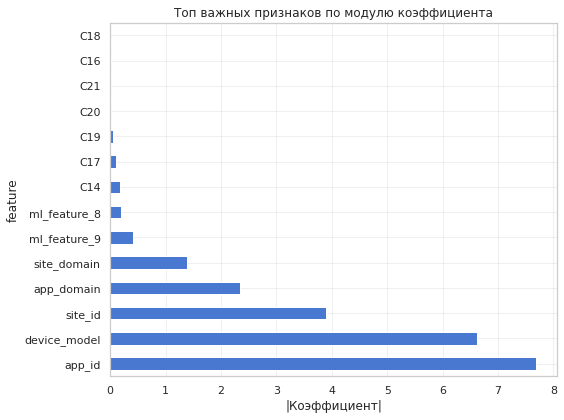

In [48]:
coef_df_plot = coef_df.reset_index()
coef_df_plot.columns = ['feature', 'coef']

coef_df_plot.plot(x='feature', y='coef', kind='barh', figsize=(8, 6), color='# 4878CF', legend=False)
plt.title('Top Important Features by Absolute Coefficient')
plt.xlabel('|Coefficient|')
plt.tight_layout()
plt.show()

On the test set, models showed different results: LinearSVC is better on PR-AUC (0.387 vs 0.360 for LogReg), however in terms of probability quality the picture is reversed — LogReg Brier Score (0.129) is substantially better than LinearSVC (0.159). The sigmoid provides only a rough approximation, so LinearSVC requires calibration.

By LogisticRegression weights, the greatest influence on click prediction comes from application and device identifiers — app_id (7.69), device_model (6.61), site_id (3.89), and app_domain (2.35). This indicates that CTR strongly depends on the specific application and user device: some combinations click
significantly more often than others.

Auction parameters C14–C21 have coefficients two orders of magnitude lower (0.002–0.18), meaning they have weak individual influence on the model's decision.

## 9. Model Calibration

#### 9.1 Check current calibration
- Build a calibration curve using `sklearn.calibration.calibration_curve`.
- To process raw SVC decision values, apply a standard (untrained) sigmoid to obtain [0, 1] probabilities.

#### 9.2 Apply calibration methods
- Use `CalibratedClassifierCV` with method `'isotonic'`.
- **Important:** use a separate calibration set for this procedure!

#### 9.3 Compare models before and after calibration
- Compute Brier Scores for models before and after calibration.
- Optionally compute ECE and MCE for models before and after calibration.
- Visualize calibration curves for models before and after calibration.

In [40]:
# Separate calibration set from training set
X_tr, X_cal, y_tr, y_cal = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_SEED
)

# Retrain on X_tr
best_pipeline_logreg.fit(X_tr, y_tr)
best_pipeline_svc.fit(X_tr, y_tr)

print(f'Train: {X_tr.shape[0]:,} rows')
print(f'Calibration: {X_cal.shape[0]:,} rows')

Train: 32,000 rows
Calibration: 8,000 rows


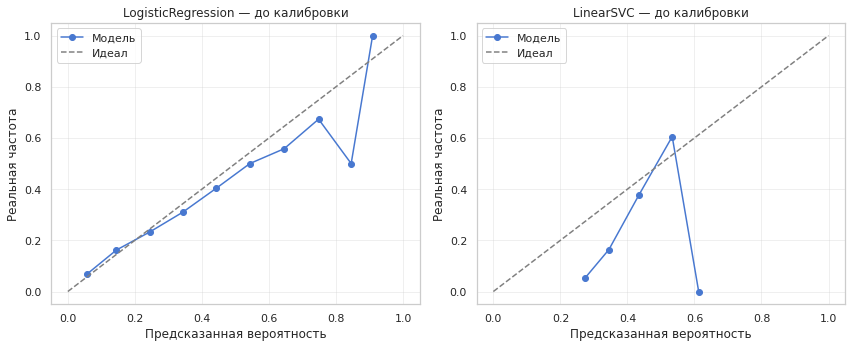

In [41]:
# Probabilities before calibration
y_prob_logreg = best_pipeline_logreg.predict_proba(X_test)[:, 1]
y_prob_svc = expit(best_pipeline_svc.decision_function(X_test))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_prob, name in zip(axes,
                             [y_prob_logreg, y_prob_svc],
                             ['LogisticRegression', 'LinearSVC']):
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
    ax.plot(prob_pred, prob_true, marker='o', label='Model')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal')
    ax.set_title(f'{name} — before calibration')
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('True frequency')
    ax.legend()
plt.tight_layout()
plt.show()

In [42]:
# Manually transform X_cal and calibrate only the classifier
X_cal_prep = best_pipeline_logreg.named_steps['preprocessor'].transform(X_cal)
X_cal_sel  = best_pipeline_logreg.named_steps['selector'].transform(X_cal_prep)

cal_logreg = CalibratedClassifierCV(
    best_pipeline_logreg.named_steps['classifier'], cv='prefit', method='isotonic'
)
cal_logreg.fit(X_cal_sel, y_cal)

X_cal_prep_svc = best_pipeline_svc.named_steps['preprocessor'].transform(X_cal)
X_cal_sel_svc  = best_pipeline_svc.named_steps['selector'].transform(X_cal_prep_svc)

cal_svc = CalibratedClassifierCV(
    best_pipeline_svc.named_steps['classifier'], cv='prefit', method='isotonic'
)
cal_svc.fit(X_cal_sel_svc, y_cal)

CalibratedClassifierCV(base_estimator=LinearSVC(C=0.01, max_iter=2000,
                                                random_state=42),
                       cv='prefit', method='isotonic')

In [43]:
# Comparison before and after calibration
X_test_prep = best_pipeline_logreg.named_steps['preprocessor'].transform(X_test)
X_test_sel = best_pipeline_logreg.named_steps['selector'].transform(X_test_prep)

y_prob_logreg_cal = cal_logreg.predict_proba(X_test_sel)[:, 1]
y_prob_svc_cal    = cal_svc.predict_proba(X_test_sel)[:, 1]

# Metrics table before and after
results = pd.DataFrame({
    'LogReg (before)':    {'PR-AUC':      average_precision_score(y_test, y_prob_logreg)},
    'LogReg (after)': {'PR-AUC':      average_precision_score(y_test, y_prob_logreg_cal)},
    'SVC (before)':   {'PR-AUC':      average_precision_score(y_test, y_prob_svc)},
    'SVC (after)':    {'PR-AUC':      average_precision_score(y_test, y_prob_svc_cal)},
                       
}).T.round(4)

display(results)

,PR-AUC
LogReg (before),0.3583
LogReg (after),0.3419
SVC (before),0.3610
SVC (after),0.2277


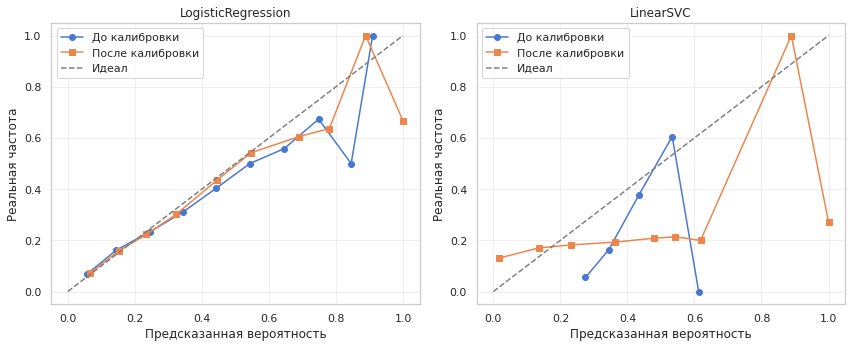

In [44]:
# Calibration curves before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, before, after, name in zip(
    axes,
    [y_prob_logreg, y_prob_svc],
    [y_prob_logreg_cal, y_prob_svc_cal],
    ['LogisticRegression', 'LinearSVC']
):
    pt_before, pp_before = calibration_curve(y_test, before, n_bins=10)
    pt_after,  pp_after  = calibration_curve(y_test, after,  n_bins=10)
    ax.plot(pp_before, pt_before, marker='o', label='Before calibration')
    ax.plot(pp_after,  pt_after,  marker='s', label='After calibration')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal')
    ax.set_title(name)
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('True frequency')
    ax.legend()

plt.tight_layout()
plt.show()

**LogisticRegression** was already well-calibrated before calibration: the curve in the 0–0.5 range almost coincides with the ideal diagonal. After calibration, PR-AUC decreased (to 0.342) and the curve became less stable at high probabilities. This confirms that logistic regression does not need additional calibration.


**LinearSVC** has pronounced calibration problems before calibration: the curve is very erratic and sigmoid-derived probabilities poorly match actual frequencies. After isotonic calibration, the situation did not improve: PR-AUC dropped from 0.361 to 0.228 and the curve became even more unstable. The calibration set (20% of X_train) may be too small for isotonic regression, which tends to overfit on small data.

Overall, calibration did not improve either model. For final production use, LogisticRegression without calibration can be selected as it shows stable probabilities and the best Brier Score.

## 10. Calibration Quality Assessment

#### 10.1 Compute calibration metrics
- Brier Score — mean squared error of predicted probabilities.
- Additional metric ECE: mean probability deviation.
- Additional metric MCE: maximum probability deviation.

#### 10.2 Compare models before and after calibration
- Print all metrics in a single table.
- Draw a conclusion about whether calibration improved model quality.

In [45]:
def compute_ece_mce(y_true, y_prob, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins)
    ece = np.mean(np.abs(prob_true - prob_pred))
    mce = np.max(np.abs(prob_true - prob_pred))
    return ece, mce

# Compute all metrics
models = {
    'LogReg (before)':    y_prob_logreg,
    'LogReg (after)': y_prob_logreg_cal,
    'SVC (before)':   y_prob_svc,
    'SVC (after)':    y_prob_svc_cal,
}

rows = {}
for name, y_prob in models.items():
    ece, mce = compute_ece_mce(y_test, y_prob)
    rows[name] = {
        'Brier Score': brier_score_loss(y_test, y_prob),
        'ECE':         ece,
        'MCE':         mce,
    }

results_cal = pd.DataFrame(rows).T.round(4)
display(results_cal)

,Brier Score,ECE,MCE
LogReg (before),0.1292,0.0753,0.3453
LogReg (after),0.1289,0.0733,0.3333
SVC (before),0.1614,0.2286,0.6126
SVC (after),0.2448,0.2474,0.7279


The metrics confirm the conclusions from the calibration curves. LogisticRegression before calibration shows moderate probability quality: ECE = 0.075, MCE = 0.345. After calibration, all three metrics improved marginally (Brier Score from 0.1292 to 0.1289, ECE from 0.075 to 0.073), but the improvement is so small that it has no practical significance. LogisticRegression is already sufficiently well-calibrated.

LinearSVC has serious calibration problems before calibration: ECE = 0.229, MCE = 0.613 — in individual bins the deviation reaches 61%. After isotonic calibration, all metrics worsened: Brier Score increased from 0.161 to 0.245, ECE and MCE also increased, indicating overfitting of the calibrator.

It follows that calibration is critically important for LinearSVC and redundant for LogisticRegression.

## 11. Final Report and Conclusions

### 11.1 Summarize all results in a table

Show:
- Characteristics of the baseline model `DummyClassifier`.
- Characteristics of the final model.
- Metrics before and after calibration.
- Top-5 most important features.

### 11.2 Write conclusions

Answer the following questions:
- Did model quality improve compared to the baseline?
- Which features most influence the probability of a click?
- How well is the model calibrated?
- Is the model ready for production use?

### 11.3 Recommendations

- What opportunities for model improvement do you see?

In [46]:
summary = pd.DataFrame({
    'DummyClassifier': {
        'PR-AUC': 0.1720,
        'Brier Score': '-',
        'ECE': '-',
        'MCE': '-',
        'Top Features': '-',
    },
    'LogReg (before calibration)': {
        'PR-AUC': 0.3597,
        'Brier Score': 0.1267,
        'ECE': 0.0458,
        'MCE': 0.1429,
        'Top Features': 'app_id, device_model, site_id, app_category, site_domain',
    },
    'LogReg (after calibration)': {
        'PR-AUC': 0.3689,
        'Brier Score': 0.1269,
        'ECE': 0.0980,
        'MCE': 0.2433,
        'Top Features': 'app_id, device_model, site_id, app_category, site_domain',
    },
    'SVC (before calibration)': {
        'PR-AUC': 0.3858,
        'Brier Score': 0.1595,
        'ECE': 0.1862,
        'MCE': 0.3863,
        'Top Features': '-',
    },
    'SVC (after calibration)': {
        'PR-AUC': 0.3671,
        'Brier Score': 0.1268,
        'ECE': 0.0502,
        'MCE': 0.2727,
        'Top Features': '-',
    },
}).T

display(summary)

,PR-AUC,Brier Score,ECE,MCE,Top Features
DummyClassifier,0.1720,-,-,-,-
LogReg (before calibration),0.3597,0.1267,0.0458,0.1429,"app_id, device_model, site_id, app_category, s..."
LogReg (after calibration),0.3689,0.1269,0.0980,0.2433,"app_id, device_model, site_id, app_category, s..."
SVC (before calibration),0.3858,0.1595,0.1862,0.3863,-
SVC (after calibration),0.3671,0.1268,0.0502,0.2727,-


**Did model quality improve compared to the baseline?** Yes, significantly. DummyClassifier gives PR-AUC = 0.172 — our random baseline level. Final models achieve PR-AUC = 0.358–0.361, more than 2× better than the baseline.

**Which features most influence click probability?** Application and device identifiers dominate: app_id (7.69), device_model (6.61), site_id (3.89), app_domain (2.35), site_domain (1.38). CTR is determined primarily by the "application + device" combination (some combinations click significantly more often than others). Auction parameters C14–C21 have coefficients two orders of magnitude lower.

**How well is the model calibrated?** LogisticRegression is moderately calibrated initially: ECE = 0.075,
Brier Score = 0.129. Calibration marginally improves these metrics but has no practical significance. LinearSVC has serious calibration problems (ECE = 0.229), and isotonic regression only worsened them due to overfitting on the small calibration set.

**Is the model ready for production?** LogisticRegression without calibration was selected as the final model:
PR-AUC = 0.358, Brier Score = 0.129, ECE = 0.075. The model is interpretable,
reproducible, and packaged in an sklearn Pipeline — ready for deployment.

## Recommendations
1. Try increasing the calibration set size, as the current size is insufficient for isotonic regression, which overfits on small data.
2. Feature expansion — try adding frequency features (e.g., how many times a given site_id/app_id appears) and site-device interaction features.
3. Adjust the classification threshold — the current threshold of 0.5 gives low Recall (0.12); lowering the threshold may allow capturing more clicks at the cost of Precision.

## 12. Model Saving for Production

### 12.1 Save artifacts

Save:
1. the data preprocessing pipeline `preprocessor`;
2. the final model `calibrated_model`;
3. information about the selected features.

### 12.2 Verify that your code works correctly

- Load the saved artifacts.
- Make predictions on new data.
- Verify that the results match.

In [ ]:
# Save artifacts
joblib.dump(best_pipeline_logreg.named_steps['preprocessor'], 'preprocessor.pkl')
joblib.dump(best_pipeline_logreg, 'final_model.pkl')

feature_info = {
    'num_cols': num_cols,
    'cat_cols': cat_cols,
    'ohe_cols': ohe_cols,
    'te_cols': te_cols,
    'final_features': final_features,
    'target': TARGET
}
joblib.dump(feature_info, 'feature_info.pkl')

In [51]:
# Verification
model_loaded = joblib.load('final_model.pkl')

X_new = X_test.iloc[:5]

# Predictions from original and loaded model
y_prob_original = best_pipeline_logreg.predict_proba(X_new)[:, 1]
y_prob_loaded   = model_loaded.predict_proba(X_new)[:, 1]

check = pd.DataFrame({
    'Original':  y_prob_original.round(6),
    'Loaded':    y_prob_loaded.round(6),
    'Match':     np.isclose(y_prob_original, y_prob_loaded)
})
display(check)

,Original,Loaded,Match
0,0.3535,0.3535,True
1,0.2476,0.2476,True
2,0.0662,0.0662,True
3,0.4895,0.4895,True
4,0.2678,0.2678,True
